In [1]:
import pandas as pd
import zipfile

# 1. Unzip the file
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('student_data')

# 2. Load the CSV file
# (Adjust the path if your unzipped filename varies slightly)
df = pd.read_csv('student_data/Student_performance_data _.csv')

# Display basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB
None


In [2]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


# Exploratory Data Analysis (EDA) & Data Cleaning

Missing values:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64
Duplicates: 0


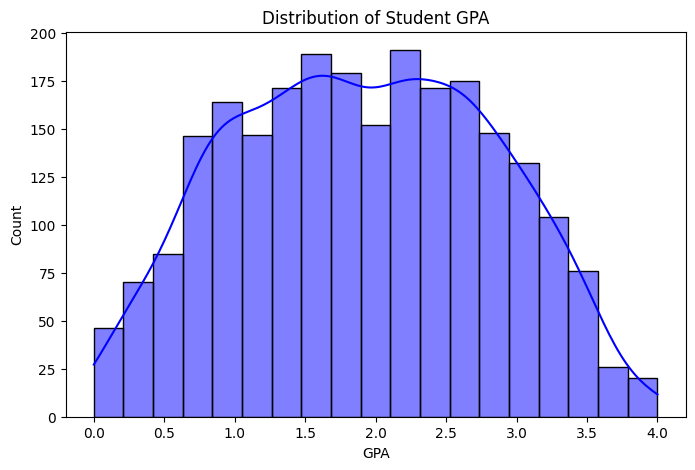

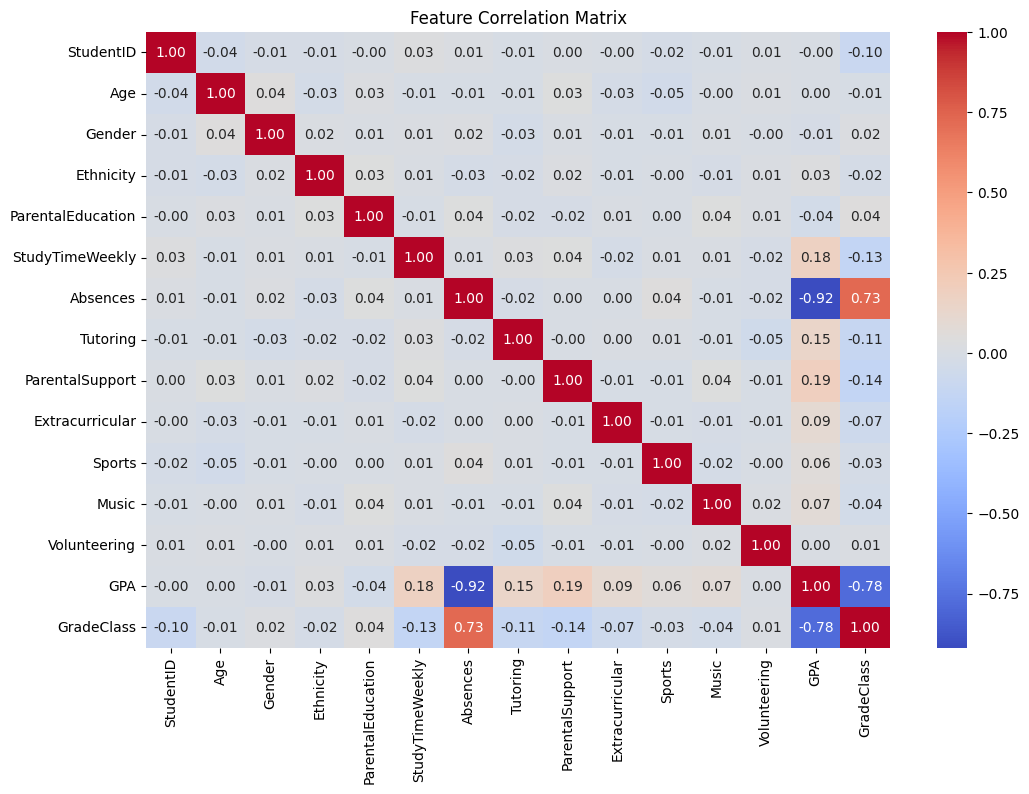

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check for missing values and duplicates
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

# 3. Basic EDA: GPA Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['GPA'], kde=True, color='blue')
plt.title('Distribution of Student GPA')
plt.xlabel('GPA')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

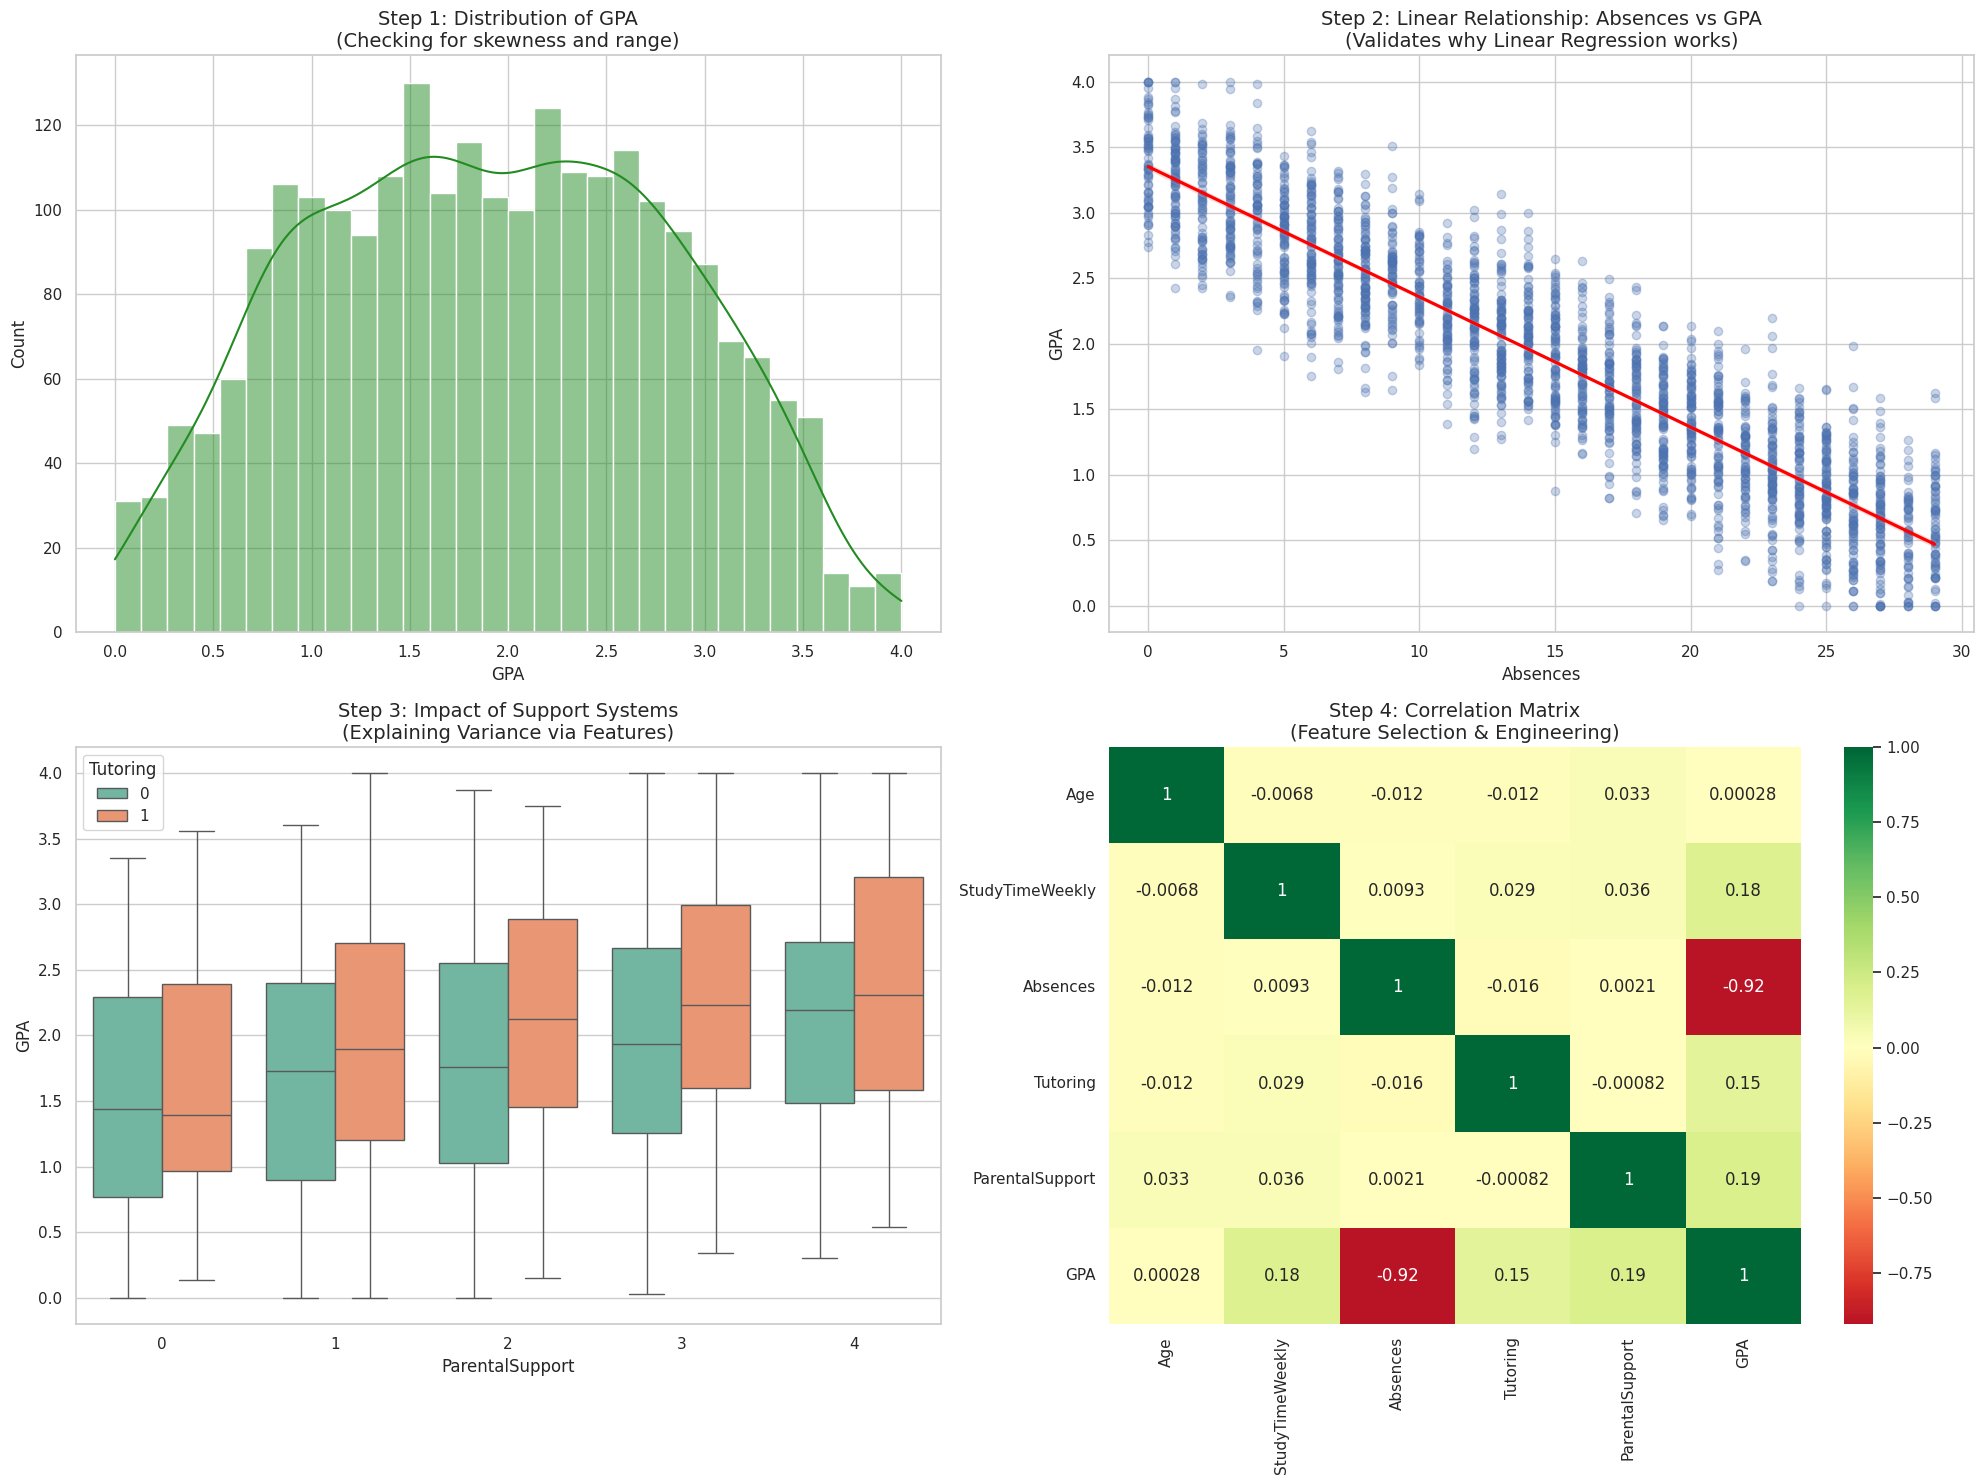

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a figure with a grid layout
plt.figure(figsize=(20, 15))

# --- 1. TARGET VARIABLE DISTRIBUTION (GPA) ---
plt.subplot(2, 2, 1)
sns.histplot(df['GPA'], kde=True, color='forestgreen', bins=30)
plt.title('Step 1: Distribution of GPA\n(Checking for skewness and range)', fontsize=14)

# --- 2. IMPACT OF ABSENCES (The strongest linear factor) ---
plt.subplot(2, 2, 2)
sns.regplot(data=df, x='Absences', y='GPA', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Step 2: Linear Relationship: Absences vs GPA\n(Validates why Linear Regression works)', fontsize=14)

# --- 3. CATEGORICAL IMPACT: Tutoring & Parental Support ---
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='ParentalSupport', y='GPA', hue='Tutoring', palette='Set2')
plt.title('Step 3: Impact of Support Systems\n(Explaining Variance via Features)', fontsize=14)

# --- 4. CORRELATION HEATMAP ---
plt.subplot(2, 2, 4)
# Selecting a subset of important features for clarity
corr_cols = ['Age', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'GPA']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Step 4: Correlation Matrix\n(Feature Selection & Engineering)', fontsize=14)

plt.tight_layout()
plt.show()

# Feature Engineering & Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 4. Feature Selection
# Drop 'StudentID' (doesn't contribute to learning) and 'GradeClass' (classification target)
X = df.drop(['StudentID', 'GPA', 'GradeClass'], axis=1)
y = df['GPA']

# 5. Model Validation: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Feature Scaling (Essential for SVR and Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Complete.")

Data Preprocessing Complete.


#Model Training and Evaluation

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# # Initialize models
# models = {
#     "Linear Regression": LinearRegression(),
#     "Support Vector Regressor": SVR(kernel='rbf'),
#     "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
# }

# # 7. Model Training & Validation Loop
# results = {}

# for name, model in models.items():
#     # Train the model
#     model.fit(X_train_scaled, y_train)

#     # Predict
#     y_pred = model.predict(X_test_scaled)

#     # Evaluate
#     mse = mean_squared_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)
#     results[name] = {"MSE": mse, "R2": r2}

#     print(f"--- {name} Results ---")
#     print(f"Mean Squared Error: {mse:.4f}")
#     print(f"R-squared: {r2:.4f}\n")

# # Summary Table
# results_df = pd.DataFrame(results).T
# print("Final Comparison:")
# print(results_df)

In [6]:
# import joblib
# from google.colab import files

# # Let's assume 'rf_model' is your trained Random Forest and 'scaler' is your fitted StandardScaler
# # Save them to the Colab local disk
# joblib.dump(models["Random Forest Regressor"], 'model.joblib')
# joblib.dump(scaler, 'scaler.joblib')

# print("Files saved locally in Colab.")

# # Step 2: Download files to your computer
# files.download('model.joblib')
# files.download('scaler.joblib')

/tmp/ipython-input-390730688.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results_df, ax=ax1, palette='viridis')


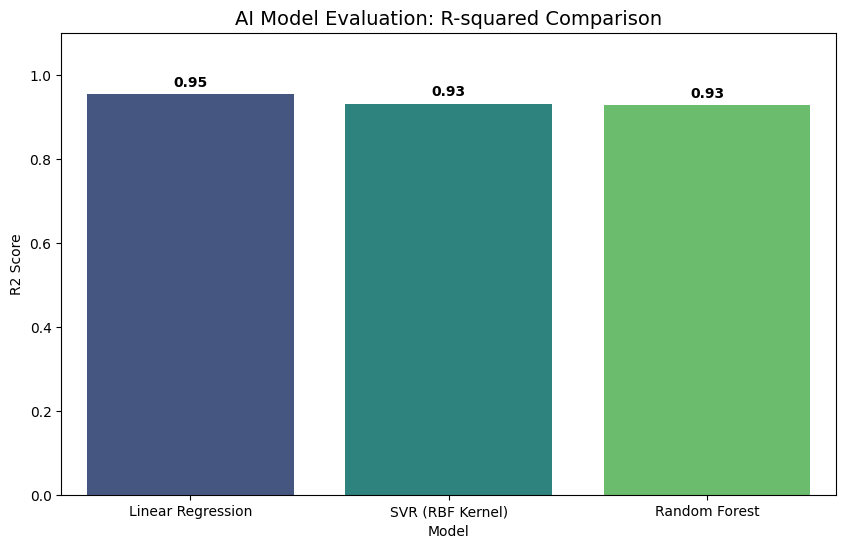

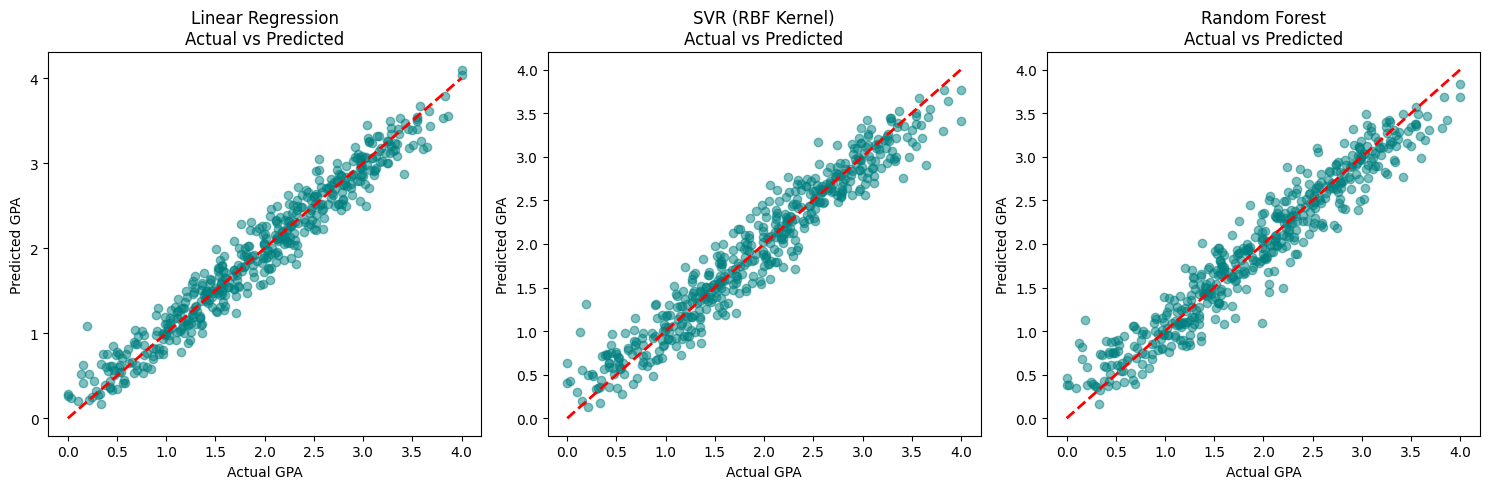

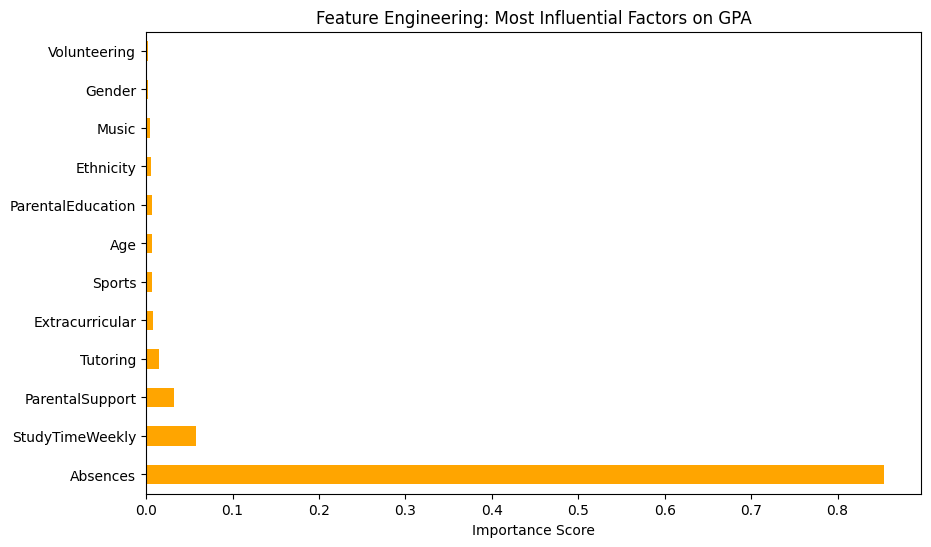

In [7]:
# 2. Train and Evaluate Models
models = {
    "Linear Regression": LinearRegression(),
    "SVR (RBF Kernel)": SVR(kernel='rbf'),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({"Model": name, "MSE": mse, "R2 Score": r2})

results_df = pd.DataFrame(results)

# --- VISUALIZATIONS FOR SLIDES ---

# Chart 1: Model Performance Comparison (R2 and MSE)
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=results_df, ax=ax1, palette='viridis')
ax1.set_title('AI Model Evaluation: R-squared Comparison', fontsize=14)
ax1.set_ylim(0, 1.1)
for i, v in enumerate(results_df['R2 Score']):
    ax1.text(i, v + 0.02, f'{v:.2f}', color='black', ha='center', fontweight='bold')
plt.show()

# Chart 2: Bias vs Variance Visualization (Actual vs Predicted)
plt.figure(figsize=(15, 5))
for i, (name, y_pred) in enumerate(predictions.items()):
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    plt.title(f'{name}\nActual vs Predicted')
    plt.xlabel('Actual GPA')
    plt.ylabel('Predicted GPA')
plt.tight_layout()
plt.show()
